In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [ ]:
import tensorflow as tf

# Check if TensorFlow is detecting the GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if len(gpus) > 0:
    print(f"Found {len(gpus)} GPU(s). Using GPU.")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPUs found. TensorFlow is using the CPU.")


Found 1 GPU(s). Using GPU.


In [ ]:
from tensorflow.keras import layers, models, optimizers, losses, metrics
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.preprocessing import LabelEncoder

In [4]:
data = pd.read_excel("D:/Ruslan/main.xlsx")
print(data.head())
print("Unique conditions (raw):", data['Condition'].unique())

   IMG name  Voltage, V  Current, A Condition
0         1       20.21       2.000     clean
1         2       20.27       2.006     clean
2         3       20.33       2.010     clean
3         4       20.33       2.009     clean
4         5       20.32       2.007     clean
Unique conditions (raw): ['clean' 'water' 'dust' 'snow']


In [5]:
# 2) LABEL ENCODE THE CONDITION COLUMN
#    Mapping -> {'clean': 0, 'dust': 1, 'snow': 2, 'water': 3}

labelencoder = LabelEncoder()
data['Condition'] = labelencoder.fit_transform(data['Condition'])
print("Unique conditions (encoded):", data['Condition'].unique())

Unique conditions (encoded): [0 3 1 2]


In [ ]:
image_dir = "D:/Ruslan/main/"
data['ImagePath'] = data['IMG name'].apply(
    lambda x: os.path.join(image_dir, f"{x}.jpg")
)
print(data[['IMG name','Condition','ImagePath']].head())

   IMG name  Condition             ImagePath
0         1          0  D:/Ruslan/main/1.jpg
1         2          0  D:/Ruslan/main/2.jpg
2         3          0  D:/Ruslan/main/3.jpg
3         4          0  D:/Ruslan/main/4.jpg
4         5          0  D:/Ruslan/main/5.jpg


In [7]:
# 4) CUSTOM SPLIT: HARDCODED TEST RANGES PER CONDITION
#    (CLEAN, WATER, DUST, SNOW)

def assign_split(row):
    img_name = row['IMG name']
    cond = row['Condition']
    
    if cond == 0:  # clean
        if 428 <= img_name <= 603:
            return 'test'
        else:
            return 'train_val'
    elif cond == 3:  # water
        if 1006 <= img_name <= 1156:
            return 'test'
        else:
            return 'train_val'
    elif cond == 1:  # dust
        if 2901 <= img_name <= 3029:
            return 'test'
        else:
            return 'train_val'
    elif cond == 2:  # snow
        if 3370 <= img_name <= 3630:
            return 'test'
        else:
            return 'train_val'
    else:
        return 'train_val'

data['Split'] = data.apply(assign_split, axis=1)

test_data = data[data['Split'] == 'test'].copy()
train_val_data = data[data['Split'] == 'train_val'].copy()


In [8]:
# split train_val data into train and validation
# train_data = 66.255%, val_data = 15.29%, test_data = 18.4%

train_data, val_data = train_test_split(
    train_val_data, test_size = 0.1875,
    random_state = 42,
    stratify = train_val_data['Condition']
)

print("Train data size:", train_data.shape[0])
print("Validation data size:", val_data.shape[0])
print("Test data size:", test_data.shape[0])

# print("\nClass distribution in train_data:")
# print(train_data['Condition'].value_counts())

# print("\nClass distribution in val_data:")
# print(val_data['Condition'].value_counts())

# print("\nClass distribution in test_data:")
# print(test_data['Condition'].value_counts())

Train data size: 2846
Validation data size: 657
Test data size: 717


In [ ]:
#5 dataset prepatation pipeline
#IMG_SIZE = (3024, 4032)
IMG_SIZE = (224, 224)

def load_image_and_labels(filename, condition, augment=False):
    """Load + decode + resize. If augment=True, apply data_aug. Returns (image, label)."""
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    #condition_one_hot = tf.one_hot(condition, depth=4)
    #regression_values = tf.stack([voltage, current], axis=-1)
    condition = tf.cast(condition, tf.int32)
    return image, condition

    # return image, {
    #     #'condition': condition_one_hot,
    #     'regression': regression_values
    # }

def df_to_dataset(df, shuffle = True, batch_size = 32, augment = False):
    filenames = df['ImagePath'].values
    conditions = df['Condition'].values
    # voltages = df['Voltage, V'].values
    # currents = df['Current, A'].values

    ds = tf.data.Dataset.from_tensor_slices((filenames, conditions ))#, voltages, currents))
    if shuffle:
        ds = ds.shuffle(buffer_size = len(df), reshuffle_each_iteration = True)
    ds = ds.map(lambda f, c: load_image_and_labels(f, c, augment = augment),
                num_parallel_calls = tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
train_ds = df_to_dataset(train_data, shuffle=True,  batch_size=32, augment=False)
val_ds   = df_to_dataset(val_data,   shuffle=False, batch_size=32, augment=False)
test_ds  = df_to_dataset(test_data,  shuffle=False, batch_size=32, augment=False)

In [11]:
def build_vgg_one_block_classification(input_shape=(224, 224, 3), num_classes = 4):
    """
    Builds a VGG-inspired model with the first block and a classification head.

    """
    inputs = layers.Input(shape=input_shape)

    # First block (Block 1)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1')(inputs)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2')(x)
    x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool')(x)

    # # # Second block (Block 2)
    # x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1')(x)
    # x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2')(x)
    # x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool')(x)

    # # Third block (Block 3)
    # x = layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1')(x)
    # x = layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2')(x)
    # x = layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3')(x)
    # x = layers.MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool')(x)

    # # Fourth block (Block 4)
    # x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block4_conv1')(x)
    # x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block4_conv2')(x)
    # x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block4_conv3')(x)
    # x = layers.MaxPooling2D((2, 2), strides = (2, 2), name = 'block4_pool')(x)

    # Fifth block (Block 5)
    # x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block5_conv1')(x)
    # x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block5_conv2')(x)
    # x = layers.Conv2D(512, (3, 3), activation = 'relu', padding = 'same', name = 'block5_conv3')(x)
    # x = layers.MaxPooling2D((2, 2), strides = (2, 2), name = 'block5_pool')(x)

    # Flatten and Fully Connected Classification Head
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(256, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.5, name='dropout1')(x)

    # Output regression layer
    outputs = layers.Dense(num_classes, activation='softmax', name='classification')(x)

    # Create model
    model = models.Model(inputs=inputs, outputs=outputs, name='VGG_One_Blocks_Classification')

    return model


In [ ]:
model = build_vgg_one_block_classification(input_shape=(224, 224, 3), num_classes=4)

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy()]
)

# Define callbacks for training
save_dir = "D:/Ruslan/ModelWeights/"
os.makedirs(save_dir, exist_ok=True)
weights_path = os.path.join(save_dir, "classification_vgg_one_blocks_weights_epoch200_224x224.h5")

checkpoint_cb = ModelCheckpoint(
    filepath=weights_path,
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)

early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    patience=200,
    restore_best_weights=True,
    verbose=1
)

# Train the model
with tf.device('/GPU:0'):

    history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[checkpoint_cb, early_stopping_cb]
) 

Epoch 1/200
89/89 [==============================] - ETA: 0s - loss: 1.1087 - sparse_categorical_accuracy: 0.6940
Epoch 1: val_loss improved from inf to 0.32924, saving model to D:/Ruslan/ModelWeights\classification_vgg_one_blocks_weights_epoch200_224x224.h5
89/89 [==============================] - 231s 3s/step - loss: 1.1087 - sparse_categorical_accuracy: 0.6940 - val_loss: 0.3292 - val_sparse_categorical_accuracy: 0.8798
Epoch 2/200
89/89 [==============================] - ETA: 0s - loss: 0.2823 - sparse_categorical_accuracy: 0.9048
Epoch 2: val_loss improved from 0.32924 to 0.23625, saving model to D:/Ruslan/ModelWeights\classification_vgg_one_blocks_weights_epoch200_224x224.h5
89/89 [==============================] - 231s 3s/step - loss: 0.2823 - sparse_categorical_accuracy: 0.9048 - val_loss: 0.2362 - val_sparse_categorical_accuracy: 0.9269
Epoch 3/200
89/89 [==============================] - ETA: 0s - loss: 0.1616 - sparse_categorical_accuracy: 0.9480
Epoch 3: val_loss improved f

In [ ]:
# 15 Evaluate the model
test_loss,test_acc = model.evaluate(test_ds)


print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_ds:.4f}")

23/23 [==============================] - 46s 2s/step - loss: 2.1205 - sparse_categorical_accuracy: 0.7810


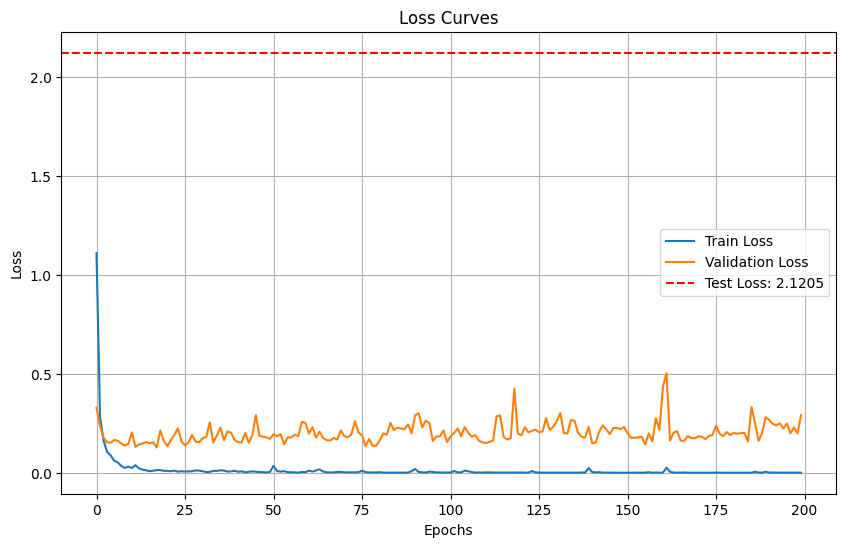

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot training and validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

# Evaluate the model on the test set (once after training)
test_loss, test_acc = model.evaluate(test_ds)
plt.axhline(test_loss, color='red', linestyle='--', label=f'Test Loss: {test_loss:.4f}')

plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
model.summary()

Model: "VGG_One_Blocks_Classification"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 flatten (Flatten)           (None, 802816)            0         
                                                                 
 fc1 (Dense)                 (None, 256)               205521152 
                                                                 
 dropout1 (Dropout)          (None, 2

1/1 [==============================] - 0s 477ms/step


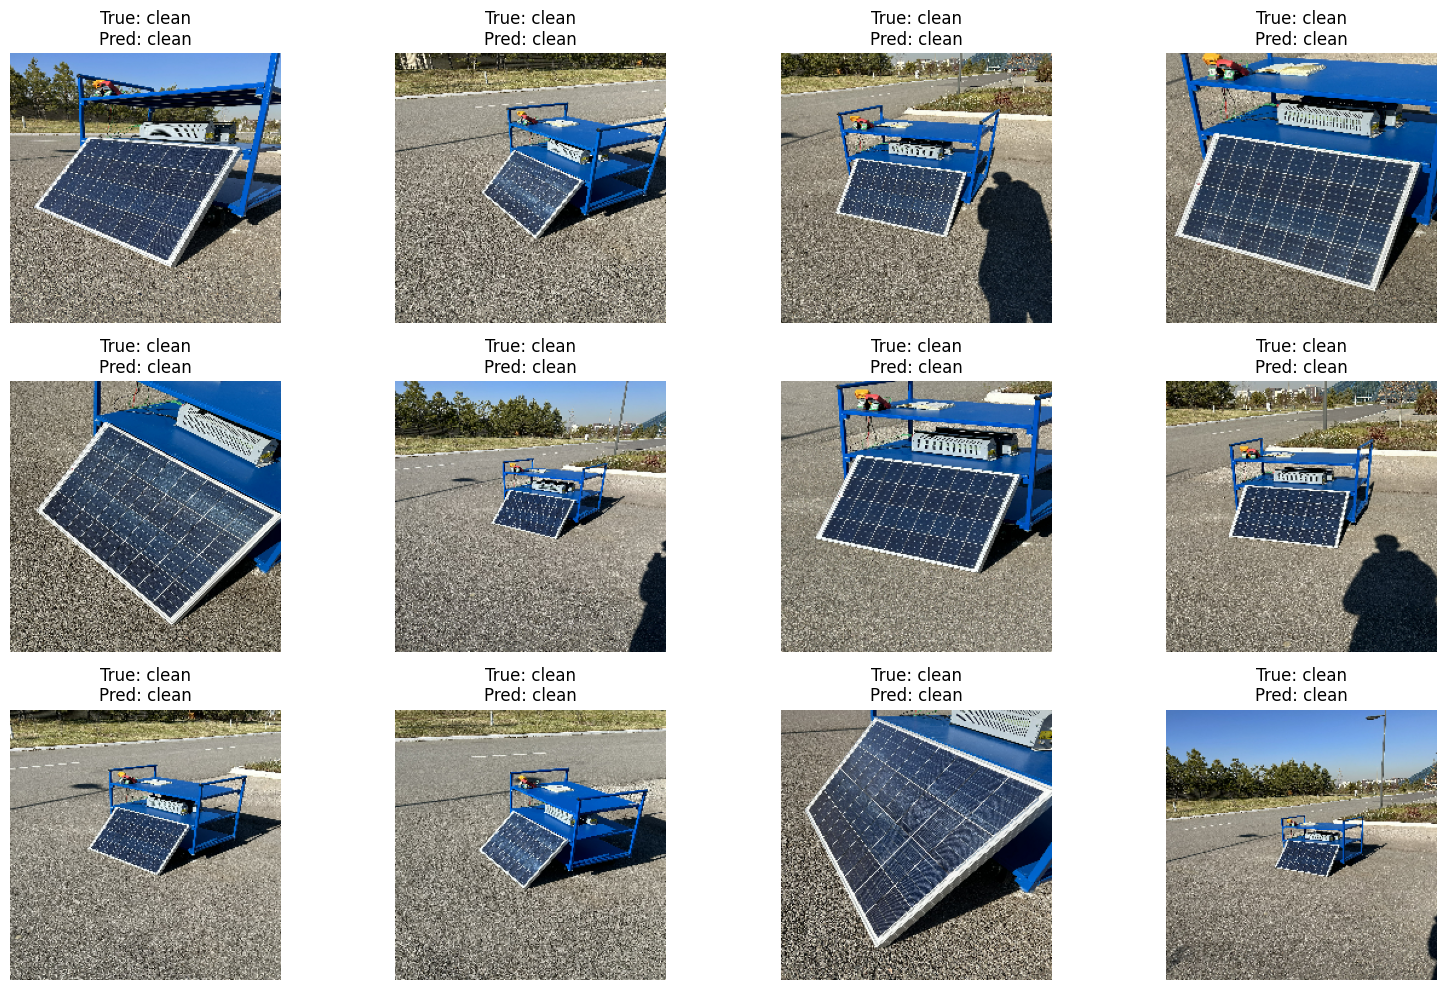

In [16]:
# 11) OPTIONAL: EXAMPLE PREDICTIONS
def show_sample_predictions(test_ds, model, sample_count=12):
    # We'll display up to 'sample_count' images from test_ds
    class_names = ["clean", "dust", "snow", "water"]  # Update accordingly

    images = []
    labels = []
    preds = []

    # We only need as many images as 'sample_count'
    count = 0
    for image_batch, label_batch in test_ds:
        batch_size = image_batch.shape[0]
        # Predict
        predictions = model.predict(image_batch)
        pred_classes = tf.argmax(predictions, axis=1)

        for i in range(batch_size):
            if count >= sample_count:
                break
            images.append(image_batch[i].numpy())
            labels.append(label_batch[i].numpy())
            preds.append(pred_classes[i].numpy())
            count += 1
        
        if count >= sample_count:
            break

    # Plot
    fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))
    axes = axes.flatten()

    for idx, ax in enumerate(axes[:sample_count]):
        ax.imshow(images[idx])
        ax.axis('off')
        true_label = class_names[labels[idx]]
        pred_label = class_names[preds[idx]]
        ax.set_title(f"True: {true_label}\nPred: {pred_label}")

    plt.tight_layout()
    plt.show()

# Show predictions for 12 images
show_sample_predictions(test_ds, model, sample_count=12)

In [17]:
# When creating your test dataset, shuffle it:
test_ds = df_to_dataset(test_data, shuffle=True, batch_size=32, augment=False)


1/1 [==============================] - 0s 25ms/step


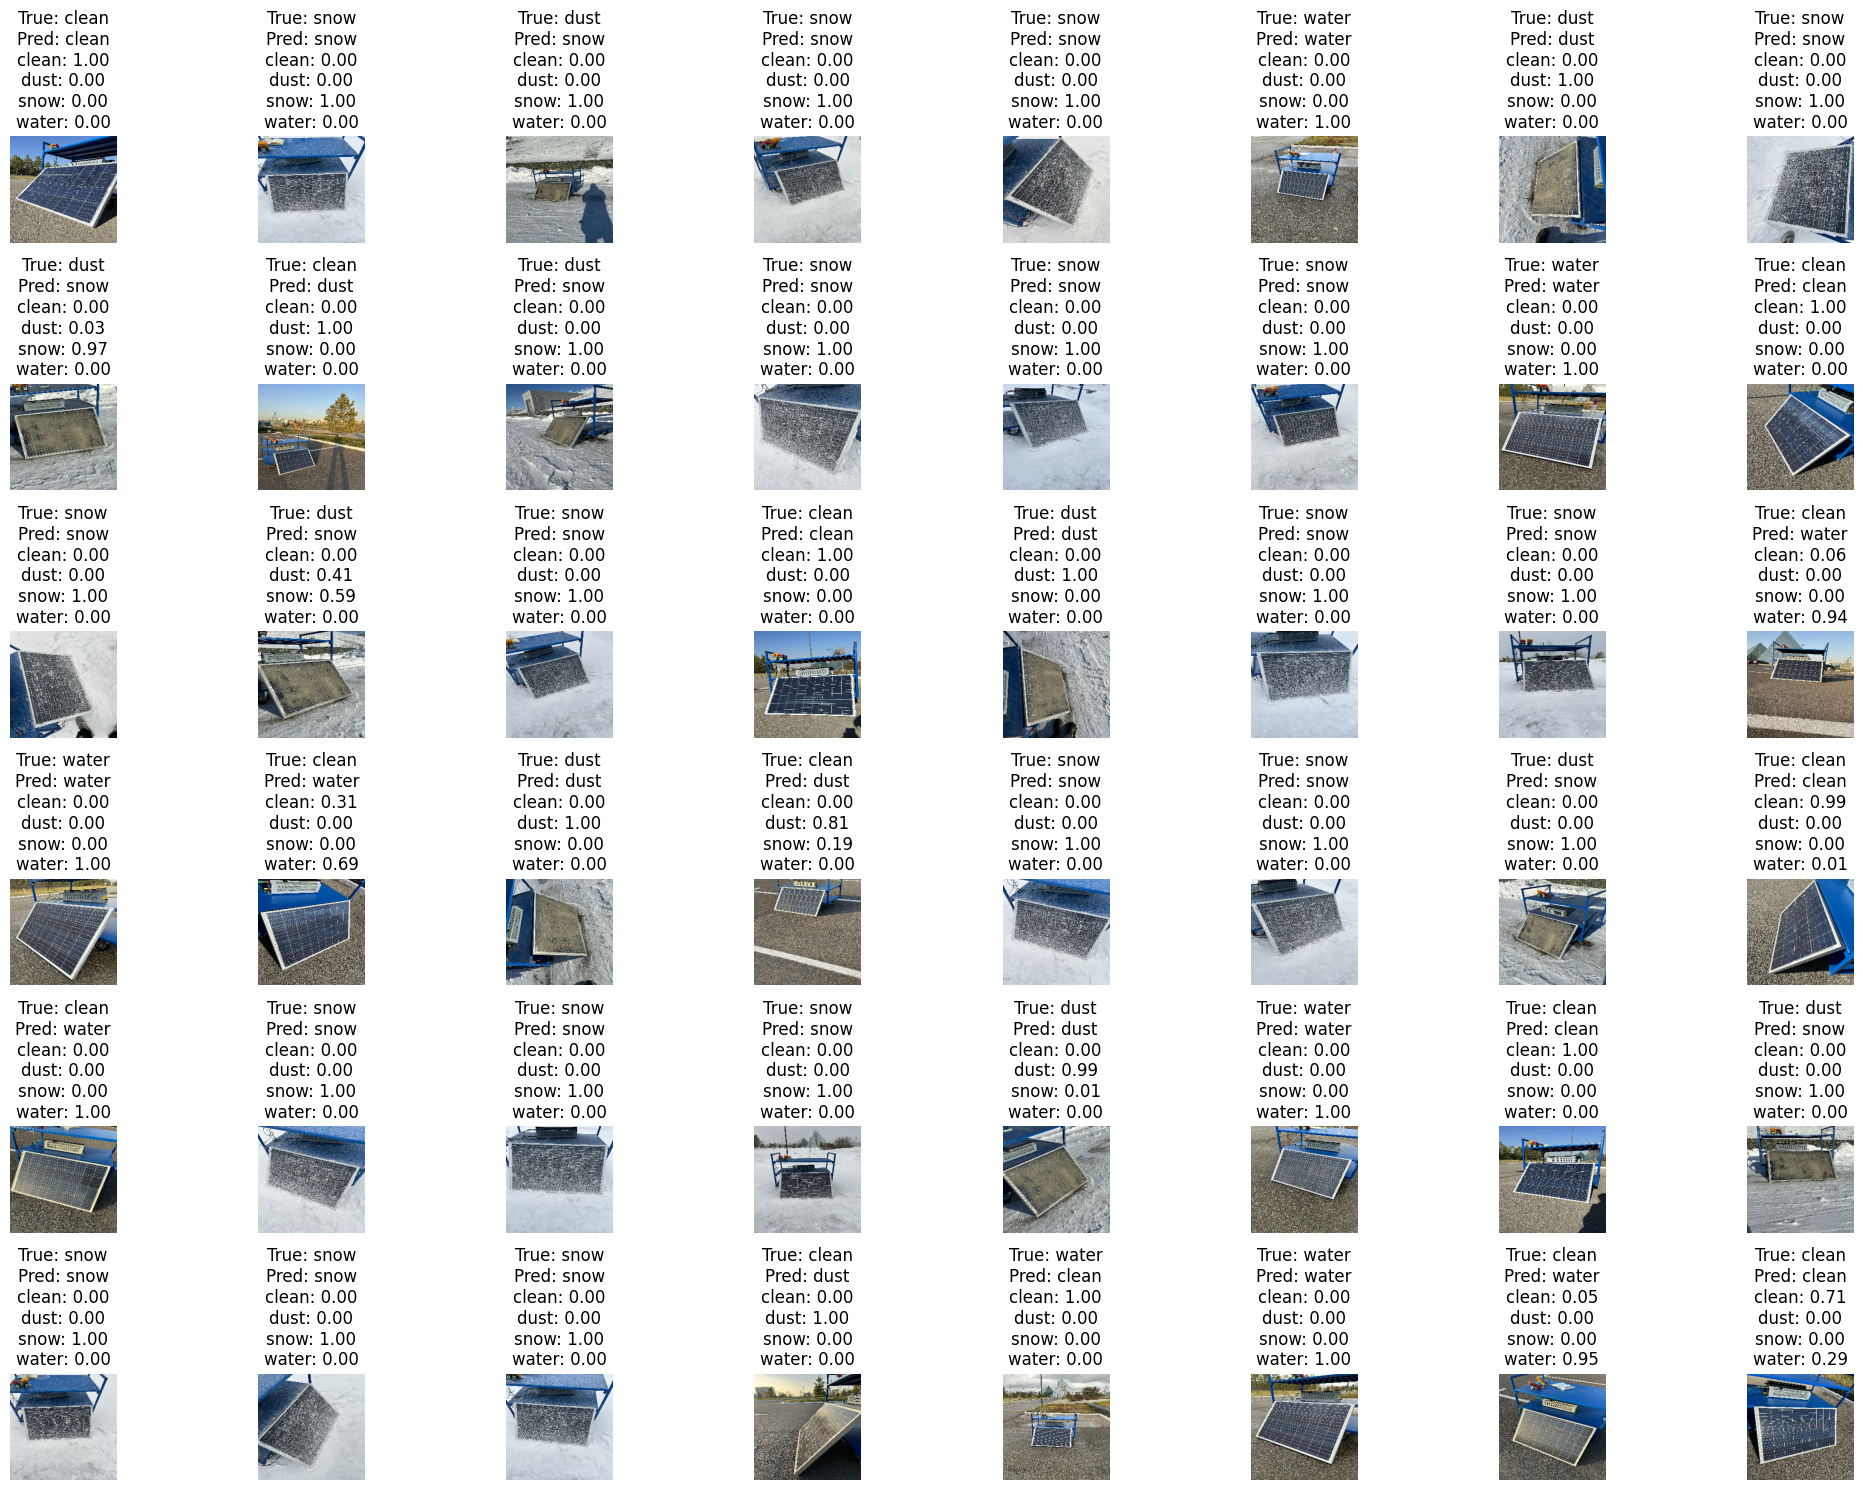

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def show_sample_predictions(test_ds, model, sample_count=48):
    # We'll display up to 'sample_count' images from test_ds
    class_names = ["clean", "dust", "snow", "water"]  # Update accordingly

    images = []
    labels = []
    preds = []
    pred_probs = []

    # We only need as many images as 'sample_count'
    count = 0
    # Shuffle the dataset before sampling images
    test_ds = test_ds.shuffle(buffer_size=1000)  # You can adjust buffer size based on the dataset size
    for image_batch, label_batch in test_ds:
        batch_size = image_batch.shape[0]
        # Predict
        predictions = model.predict(image_batch)
        
        for i in range(batch_size):
            if count >= sample_count:
                break
            images.append(image_batch[i].numpy())
            labels.append(label_batch[i].numpy())
            pred_probs.append(predictions[i])  # Store all class probabilities for each image
            pred_classes = tf.argmax(predictions[i])  # Get the predicted class index
            preds.append(pred_classes.numpy())
            count += 1
        
        if count >= sample_count:
            break

    # Adjust the figure size to make the images larger
    fig, axes = plt.subplots(nrows=6, ncols=8, figsize=(20, 15))  # Increase figsize for larger images
    axes = axes.flatten()

    for idx, ax in enumerate(axes[:sample_count]):
        ax.imshow(images[idx])
        ax.axis('off')
        true_label = class_names[labels[idx]]
        pred_label = class_names[preds[idx]]
        # Get the probabilities for all classes
        prob_str = "\n".join([f"{class_names[i]}: {prob:.2f}" for i, prob in enumerate(pred_probs[idx])])
        ax.set_title(f"True: {true_label}\nPred: {pred_label}\n{prob_str}")

    plt.tight_layout()
    plt.show()

# Show predictions for 48 images
show_sample_predictions(test_ds, model, sample_count=48)
